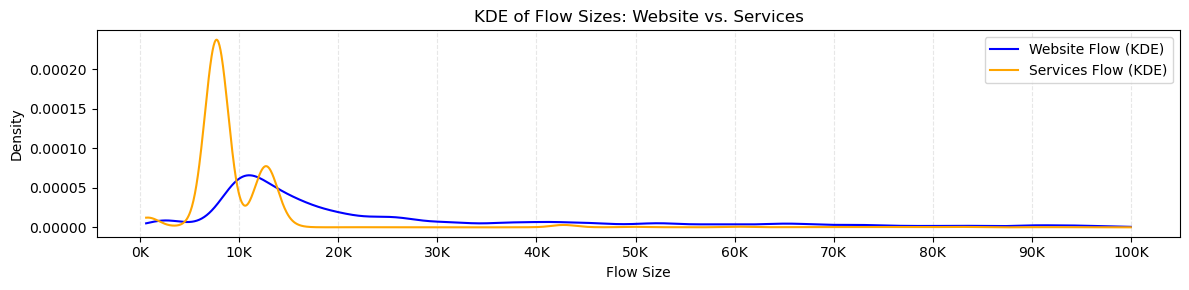

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

STAT_ROOT = "../data_extract"
protocol = "shadowsocks"
# Load the flow sizes array, whose key is "flow_size"
path = f"/data/exp/lxyu/Dataset/WF/VisualSeg/flow_size/{protocol}.npz"
website_flow = np.load(path)['flow_size']
df = pd.read_csv(f"{STAT_ROOT}/firefox.settings.services.mozilla.com.csv")
services_flow = df[protocol].dropna().to_numpy().astype(np.int64)

# Prepare website_flow (remove NaNs and large values)
website_flow = website_flow[~np.isnan(website_flow)]
website_flow = website_flow[website_flow < 100_000]

# Prepare services_flow (remove NaNs and large values if needed)
services_flow = services_flow[~np.isnan(services_flow)]
services_flow = services_flow[services_flow < 100_000]

# Determine x range for both curves
x_min = min(np.min(website_flow), np.min(services_flow))
x_max = max(np.max(website_flow), np.max(services_flow))
x_vals = np.linspace(x_min, x_max, 2000)

# KDEs
kde_website = gaussian_kde(website_flow)
kde_services = gaussian_kde(services_flow)

plt.figure(figsize=(12, 3))

plt.plot(x_vals, kde_website(x_vals), label='Website Flow (KDE)', color='blue')
plt.plot(x_vals, kde_services(x_vals), label='Services Flow (KDE)', color='orange')

plt.xlabel('Flow Size')
plt.ylabel('Density')

# Set the x-axis ticks to every 100K
start_tick = 0
end_tick = int(np.ceil(x_max / 10_000)) * 10_000
plt.xticks(np.arange(start_tick, end_tick + 1, 10_000),
           [f'{int(x/1000)}K' for x in np.arange(start_tick, end_tick + 1, 10_000)])
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.title('KDE of Flow Sizes: Website vs. Services')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
import numpy as np
from WFlib.tools.extractor import sni_cover
import pandas as pd

def bound_gen(*ranges: tuple):
    lower_bounds = np.array([r[0] for r in ranges])
    upper_bounds = np.array([r[1] for r in ranges])
    return lower_bounds, upper_bounds

def proportion_in_range(arr, lower_bounds, upper_bounds):
    """
    Calculate the proportion of the array that is in the range of the lower and upper bounds.
    """
    assert len(lower_bounds) == len(upper_bounds)
    in_idx = set()
    for (lower, upper) in zip(lower_bounds, upper_bounds):
        assert lower <= upper
        in_idx.update(np.where(np.logical_and(arr > lower, arr < upper))[0])
    return len(in_idx) / len(arr)

In [101]:
INTRINSIC_SNIS = ['firefox-settings-attachments.cdn.mozilla.net', 'firefox.settings.services.mozilla.com', 'content-signature-2.cdn.mozilla.net']
STAT_ROOT = "../data_extract"
PROTOCOLS = ["vmess", "trojan", "shadowsocks"]


website_flow_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
website_flow_small_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_large_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
# attachments_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
# services_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
# signature_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}

for protocol in PROTOCOLS:
    df = pd.read_csv(f"{STAT_ROOT}/firefox-settings-attachments.cdn.mozilla.net.csv")
    attachments_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    df = pd.read_csv(f"{STAT_ROOT}/firefox.settings.services.mozilla.com.csv")
    services_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    df = pd.read_csv(f"{STAT_ROOT}/content-signature-2.cdn.mozilla.net.csv")
    signature_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    # Data preparation
    website_flow = f"/data/exp/lxyu/Dataset/WF/VisualSeg/flow_size/{protocol}.npz"
    website_flow = np.load(website_flow)['flow_size']
    website_flow_small = website_flow[website_flow < 20_000]
    # Concatenate the flows of the three SNIs.
    BIH_flow = np.concatenate([attachments_flow, services_flow, signature_flow])
    BIH_flow_large = BIH_flow[BIH_flow > 1_000_000]
    for coverage in range(10):
        # Given coverage, we first calculate the total cover of the intrinsic SNIs.
        total_cover = []
        for sni in INTRINSIC_SNIS:
            cover, _ = sni_cover(STAT_ROOT, protocol, sni, float(coverage)/10)
            total_cover += cover
        lower_bounds, upper_bounds = bound_gen(*total_cover)

        website_flow_remaining[protocol].append(1 - proportion_in_range(website_flow, lower_bounds, upper_bounds))
        website_flow_small_remaining[protocol].append(1 - proportion_in_range(website_flow_small, lower_bounds, upper_bounds))
        BIH_flow_large_filtered[protocol].append(proportion_in_range(BIH_flow_large, lower_bounds, upper_bounds))
        BIH_flow_filtered[protocol].append(proportion_in_range(BIH_flow, lower_bounds, upper_bounds))
        # attachments_filtered[protocol].append(proportion_in_range(attachments_flow, lower_bounds, upper_bounds))
        # services_filtered[protocol].append(proportion_in_range(services_flow, lower_bounds, upper_bounds))
        # signature_filtered[protocol].append(proportion_in_range(signature_flow, lower_bounds, upper_bounds))


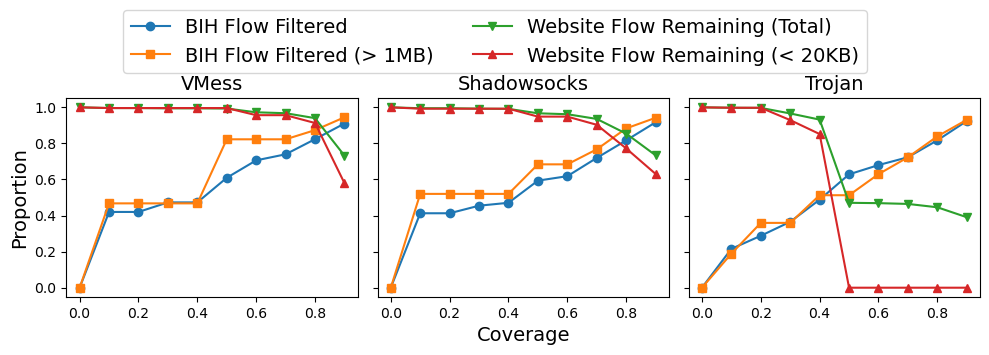

In [102]:
# After collecting the statistics, draw a 1x3 plot for the 5 arrays.
import matplotlib.pyplot as plt

coverage_range = [i/10 for i in range(10)]
array_dicts = [
    BIH_flow_filtered,
    BIH_flow_large_filtered,
    website_flow_remaining,
    website_flow_small_remaining,
    # attachments_filtered,
    # signature_filtered,
    # services_filtered,
]
array_labels = [
    "BIH Flow Filtered",
    "BIH Flow Filtered (> 1MB)",
    "Website Flow Remaining (Total)",
    "Website Flow Remaining (< 20KB)",
    # "Attachments filtered",
    # "Signature filtered",
    # "Services filtered"
]
# marker_dict = ['o', 's', 'v', '^', 'D']
marker_dict = ['o', 's', 'v', '^',]

protocols_display = ['VMess', 'Shadowsocks', 'Trojan']

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
lines = []
labels = []
for idx, protocol in enumerate(protocols_display):
    ax = axes[idx]
    for arr_idx, array in enumerate(array_dicts):
        line, = ax.plot(
            coverage_range,
            array[protocol.lower()],
            marker=marker_dict[arr_idx],
            label=array_labels[arr_idx]
        )
        if idx == 0:
            lines.append(line)
            labels.append(array_labels[arr_idx])
    ax.set_title(protocol, fontsize=14)
    if idx == 1:
        ax.set_xlabel("Coverage", fontsize=14)
    if idx == 0:
        ax.set_ylabel("Proportion", fontsize=14)
    # Remove per-axis legends for shared legend
# Place the shared legend below all the subplots
fig.legend(lines, labels, loc='upper center', ncol=(2, 2), bbox_to_anchor=(0.5, 1.2), fontsize=14)
plt.tight_layout()
plt.show()